# 2.4 Derivatives and Differentiation

Training a neural network means adjusting its parameters to decrease a loss function — and knowing *which direction* to adjust them requires the machinery of **calculus**: derivatives, gradients, and the chain rule. As the book puts it, differential calculus "can tell us how to increase or decrease a function's value by manipulating its arguments," which is exactly the tool the optimization problems in deep learning need.

We work through one running example, $f(x) = 3x^2 - 4x$, first differentiating it by hand and confirming the answer with a numerical **difference quotient**, then visualizing the result as a tangent line. From there we extend the idea to functions of several variables (**partial derivatives** and **gradients**) and to functions built by composing simpler ones (the **chain rule**) — the exact mechanism that makes backpropagation possible in the next notebook, *Automatic Differentiation*.

## 2.4.1 The Derivative as a Limit

Put simply, a **derivative** is the rate of change of a function with respect to changes in its argument. Formally, for $f:\mathbb{R}\to\mathbb{R}$, the derivative of $f$ at a point $x$ is

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}.$$

$h$ is a small perturbation of $x$; the limit tells us what the ratio $\frac{f(x+h)-f(x)}{h}$ converges to as $h$ shrinks toward (but never reaches) zero. When $f'(x)$ exists we say $f$ is *differentiable* at $x$ — and several functions we would like to optimize directly, such as classification accuracy, are not. In those cases we optimize a differentiable *surrogate* instead, which is exactly why the classifier notebooks in this repo train with cross-entropy loss while reporting accuracy on the side.

Several equivalent notations all refer to the same derivative: $f'(x) = y' = \frac{dy}{dx} = \frac{df}{dx} = \frac{d}{dx}f(x) = Df(x)$.

For functions built from familiar pieces we rarely need the limit directly — a handful of rules let us differentiate by inspection:

$$\frac{d}{dx} C = 0, \qquad \frac{d}{dx} x^n = n x^{n-1}, \qquad \frac{d}{dx} e^x = e^x, \qquad \frac{d}{dx} \ln x = x^{-1},$$

and rules for combining functions:

$$\frac{d}{dx}[Cf(x)] = C f'(x) \;(\text{constant multiple}), \qquad \frac{d}{dx}[f(x)+g(x)] = f'(x) + g'(x) \;(\text{sum}),$$

$$\frac{d}{dx}[f(x)g(x)] = f(x)g'(x) + g(x)f'(x) \;(\text{product}), \qquad \frac{d}{dx}\frac{f(x)}{g(x)} = \frac{g(x)f'(x) - f(x)g'(x)}{g(x)^2} \;(\text{quotient}).$$

We'll need `numpy` for the numerical work and `d2l`'s plotting utilities later in this section.

In [1]:
%matplotlib inline
import numpy as np                             # array ops: h-ranges below, plotting grid
from matplotlib_inline import backend_inline    # needed by use_svg_display() below
import d2l.torch as d2l                         # provides d2l.plt, used inside the helpers below

As a running example, take

$$f(x) = 3x^2 - 4x.$$

By the power rule, constant-multiple rule, and sum rule above, $\frac{d}{dx}[3x^2-4x] = 3\cdot 2x - 4 = 6x - 4$, so $f'(1) = 2$. We'll confirm this number two ways: numerically, via the difference quotient, and visually, via the tangent line.

In [2]:
# a function
def f(x):
    return 3 * x ** 2 - 4 * x   # f'(x) = 6x - 4 by the power, constant-multiple, and sum rules

Plugging $x=1$ into the difference quotient and shrinking $h$ by a factor of 10 each step, the quotient should approach $f'(1) = 2$:

In [3]:
# numerical approximation of the derivative
for h in 10.0**np.arange(-1, -6, -1):   # h = 0.1, 0.01, 0.001, 0.0001, 0.00001
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}') # fixed-point float with 5 decimal places.

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


The quotient keeps closing in on $2$ as $h$ shrinks — down to `2.00003` at $h=0.00001$ — matching the closed-form $f'(1) = 6(1)-4=2$ from the rules above. The error shrinks by roughly a factor of 10 each time $h$ does, the hallmark of this first-order finite-difference approximation. Push $h$ far enough toward zero, though, and floating-point cancellation in $f(x+h) - f(x)$ starts to dominate rather than the true error shrinking further — exactly why frameworks like PyTorch compute gradients via **automatic differentiation** (the next notebook) instead of finite differences: exact rather than approximate, and immune to this cancellation.

## 2.4.2 Visualization Utilities

To see the tangent line rather than just print its slope, we need a small plotting setup. The four helpers below are tagged `#@save`: the book folds them straight into the `d2l` package once defined, so every later chapter (and every notebook in this repo, including the Fashion-MNIST and classifier ones) can call `d2l.plot(...)`, `d2l.use_svg_display()`, etc. without redefining them.

- **`use_svg_display`** switches matplotlib's Jupyter backend to crisp SVG output.
- **`set_figsize`** sets a default figure size (and calls `use_svg_display` for us).
- **`set_axes`** applies labels, limits, scales, legend, and grid to a matplotlib `Axes`.
- **`plot`** is the workhorse: it accepts one or several curves — as tensors, arrays, or plain lists — normalizes their shapes, and draws them together via `set_axes`.

These signatures are copied verbatim from the book, since the rest of this repo depends on this exact interface — left untouched here.

In [4]:
# 2.4.2 Visualization Utilities
def use_svg_display(): #@save
    """Use the svg format to display a plot in Jupyter."""
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)): #@save
    """Set the figure size for matplotlib."""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim), axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""
    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))
    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x, y, fmt) if len(x) else axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)


The tangent line to $f$ at $x=1$ passes through $(1, f(1)) = (1, -1)$ with slope $f'(1) = 2$, so its equation is

$$y = f(1) + f'(1)(x - 1) = -1 + 2(x-1) = 2x - 3.$$

Plotting $f(x)$ and this line together should show them touching at exactly one point, $x=1$, with the line running tangent to the curve there.

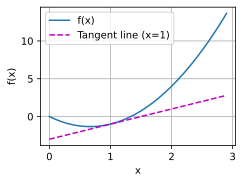

In [5]:
x = np.arange(0, 3, 0.1)   # sample points for plotting
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])   # f(x) and its tangent line y=2x-3 at x=1

As expected, the straight line grazes the curve at $x=1$ without crossing it there — visual confirmation of the same slope, $2$, that both the closed-form rule and the numerical difference quotient produced above.

## 2.4.3 Partial Derivatives and Gradients

Deep learning models are functions of many parameters at once, so we need derivatives with respect to one variable while holding the rest fixed — a **partial derivative**. For $y=f(x_1,\ldots,x_n)$,

$$\frac{\partial y}{\partial x_i} = \lim_{h \to 0} \frac{f(x_1, \ldots, x_{i-1}, x_i+h, x_{i+1}, \ldots, x_n) - f(x_1, \ldots, x_n)}{h},$$

computed by treating every variable except $x_i$ as a constant. Concatenating all $n$ partial derivatives into one vector gives the **gradient**:

$$\nabla_{\mathbf{x}} f(\mathbf{x}) = \left[\partial_{x_1} f(\mathbf{x}), \partial_{x_2} f(\mathbf{x}), \ldots, \partial_{x_n} f(\mathbf{x})\right]^\top.$$

A few gradient rules, analogous to the single-variable ones, cover the linear-algebra expressions that recur throughout this book: for a matrix $\mathbf{A}$ and vector $\mathbf{x}$,

$$\nabla_{\mathbf{x}} \mathbf{A}\mathbf{x} = \mathbf{A}^\top, \qquad \nabla_{\mathbf{x}} \mathbf{x}^\top\mathbf{A} = \mathbf{A}, \qquad \nabla_{\mathbf{x}} \mathbf{x}^\top\mathbf{A}\mathbf{x} = (\mathbf{A}+\mathbf{A}^\top)\mathbf{x}, \qquad \nabla_{\mathbf{x}} \|\mathbf{x}\|^2 = 2\mathbf{x}.$$

As a concrete check, the book's own Exercise 7 for this section asks for the gradient of $f(x_1, x_2) = 3x_1^2 + 5e^{x_2}$ — a compact example that exercises the power rule and the exponential rule, one coordinate at a time. By the rules above, $\partial f/\partial x_1 = 6x_1$ and $\partial f/\partial x_2 = 5e^{x_2}$, so $\nabla f(1, 0) = [6, 5]^\top$. Let's verify that numerically, the same way we verified $f'(1)$ earlier.

In [6]:
def f_multi(x1, x2):
    return 3 * x1 ** 2 + 5 * np.exp(x2)   # book's Exercise 7 function

x1_0, x2_0, h = 1.0, 0.0, 1e-5
df_dx1 = (f_multi(x1_0 + h, x2_0) - f_multi(x1_0, x2_0)) / h   # hold x2 fixed, vary x1
df_dx2 = (f_multi(x1_0, x2_0 + h) - f_multi(x1_0, x2_0)) / h   # hold x1 fixed, vary x2
grad_closed_form = np.array([6 * x1_0, 5 * np.exp(x2_0)])      # from the rules: df/dx1=6x1, df/dx2=5e^x2

print(f'numerical  gradient at (1,0): [{df_dx1:.4f}, {df_dx2:.4f}]')
print(f'closed-form gradient at (1,0): {grad_closed_form}')

numerical  gradient at (1,0): [6.0000, 5.0000]
closed-form gradient at (1,0): [6. 5.]


Both agree: $\nabla f(1,0) = [6, 5]^\top$. This is exactly the object that matters for training — a model's loss is a scalar function of possibly millions of parameters, and its gradient tells us, at the current parameter values, which direction increases the loss fastest (so gradient descent steps in the opposite direction).

## 2.4.4 Chain Rule

Real models are compositions of simpler functions — a linear layer feeding a nonlinearity feeding a loss — so we need to differentiate through composition. For $y=f(u)$ where $u=g(x)$, the **chain rule** says

$$\frac{dy}{dx} = \frac{dy}{du}\frac{du}{dx}.$$

Its multivariate generalization applies the same idea one coordinate at a time: if $y$ depends on intermediate variables $u_1,\ldots,u_m$, each of which depends on $x_i$,

$$\frac{\partial y}{\partial x_i} = \frac{\partial y}{\partial u_1}\frac{\partial u_1}{\partial x_i} + \cdots + \frac{\partial y}{\partial u_m}\frac{\partial u_m}{\partial x_i}, \qquad \nabla_{\mathbf{x}} y = \mathbf{A}\nabla_{\mathbf{u}} y,$$

where $\mathbf{A}\in\mathbb{R}^{n\times m}$ collects the derivatives of $\mathbf{u}$ with respect to $\mathbf{x}$ — evaluating the gradient becomes a vector–matrix product. This is precisely what **backpropagation** does: evaluating a function walks its computational graph *forward*; computing gradients walks the same graph *backward*, multiplying local derivatives along the way exactly as the chain rule prescribes. That backward pass is the subject of the next notebook, *Automatic Differentiation*.

As a minimal check (the book states the rule but doesn't work a numeric example), let $u(x)=x^2$ and $y(u)=3u$, so the composition is $y(x)=3x^2$ with known derivative $6x$. We compare differentiating the composition directly against chaining the two local derivatives together.

In [7]:
def u(x):
    return x ** 2        # inner function

def y_of_u(u_):
    return 3 * u_        # outer function

def y(x):
    return y_of_u(u(x))  # composition: y(x) = 3x^2, dy/dx should be 6x

x0, h = 1.0, 1e-5
dy_dx_direct  = (y(x0 + h) - y(x0)) / h                    # differentiate the composition directly
dy_du         = (y_of_u(u(x0) + h) - y_of_u(u(x0))) / h    # dy/du, evaluated at u(x0)
du_dx         = (u(x0 + h) - u(x0)) / h                    # du/dx, evaluated at x0
dy_dx_chained = dy_du * du_dx                              # chain rule: dy/dx = dy/du * du/dx

print(f'direct  dy/dx : {dy_dx_direct:.4f}')
print(f'chained dy/dx : {dy_dx_chained:.4f}  (dy/du={dy_du:.4f}, du/dx={du_dx:.4f})')

direct  dy/dx : 6.0000
chained dy/dx : 6.0000  (dy/du=3.0000, du/dx=2.0000)


Both routes agree: $dy/dx = 6$ at $x=1$, matching $6x\big|_{x=1}$. Differentiating the composition directly and chaining its two local derivatives give the same answer — the property that lets automatic differentiation compute exact gradients of arbitrarily deep computational graphs one local step at a time.

## 2.4.5 Summary

- **Derivative** = limit of the difference quotient, $f'(x) = \lim_{h\to0}\frac{f(x+h)-f(x)}{h}$; shrinking $h$ numerically converges toward the closed-form answer given by the power/constant-multiple/sum/product/quotient rules.
- Not every function is differentiable (e.g. accuracy) — when that happens we optimize a differentiable **surrogate** instead, such as cross-entropy in place of accuracy.
- Finite-difference approximations are only approximate and degrade for very small $h$ due to floating-point cancellation — the motivation for **automatic differentiation**, covered next.
- The `#@save`-tagged **`use_svg_display`**, **`set_figsize`**, **`set_axes`**, and **`plot`** helpers are book-canonical utilities, reused unchanged throughout this repo.
- A tangent line at $x=a$ is $y = f(a) + f'(a)(x-a)$; plotting it alongside $f$ is a visual check that the computed slope is correct.
- **Partial derivative** $\partial y/\partial x_i$ differentiates with respect to one variable, holding the rest fixed; the **gradient** $\nabla_{\mathbf x} f(\mathbf x)$ stacks all of them into a vector — the object gradient descent follows downhill.
- The **chain rule**, $dy/dx=(dy/du)(du/dx)$ and its multivariate form $\nabla_{\mathbf x} y = \mathbf A\nabla_{\mathbf u} y$, differentiates compositions of functions one piece at a time. Evaluating a computational graph is a *forward* pass; computing its gradients is a *backward* pass that multiplies local derivatives along the way — the procedure **backpropagation** automates, next.